# 2 Solving the model numerically

### 2.1 A two-dimensional grid search

In [54]:
%load_ext autoreload
%autoreload 2

from types import SimpleNamespace
from functools import partial
import time

from scipy import optimize
import numpy as np

import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
from Our_Consumer import ConsumerClass

In [56]:
model_complements = ConsumerClass()
model_complements.solve_grid();


s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


In [57]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

model_subtitutes.solve_grid();

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


### 2.1.2 Plot

#### Bus and train complements

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


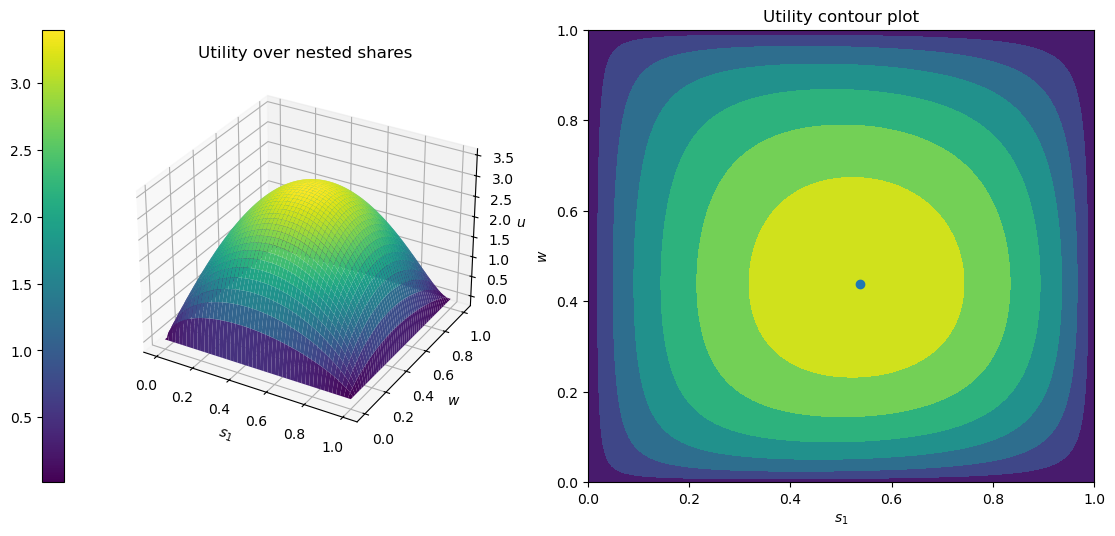

In [58]:
model_complements = ConsumerClass()

opt_complements = model_complements.solve_grid(N=200)
fig= model_complements.plot_grid(opt_complements)

#### Bus and trains subtitutes

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


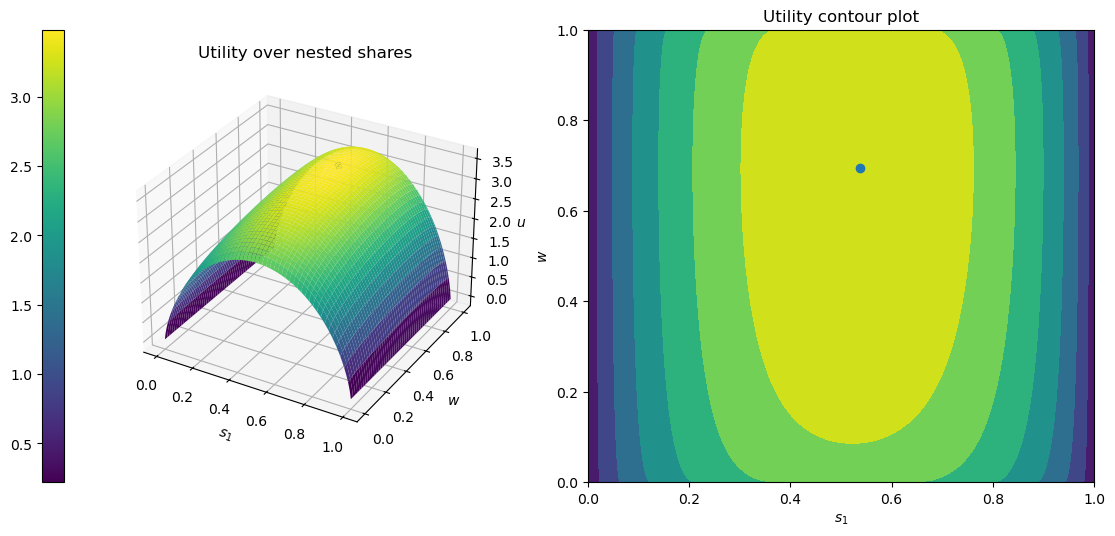

In [59]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=200)
fig= model_subtitutes.plot_grid(opt_subtitutes)

### 2.1.3 Different values of N

#### Bus and train complements

s1=0.5306
s2=0.2107
s3=0.2586
w=0.4490
u=3.4007


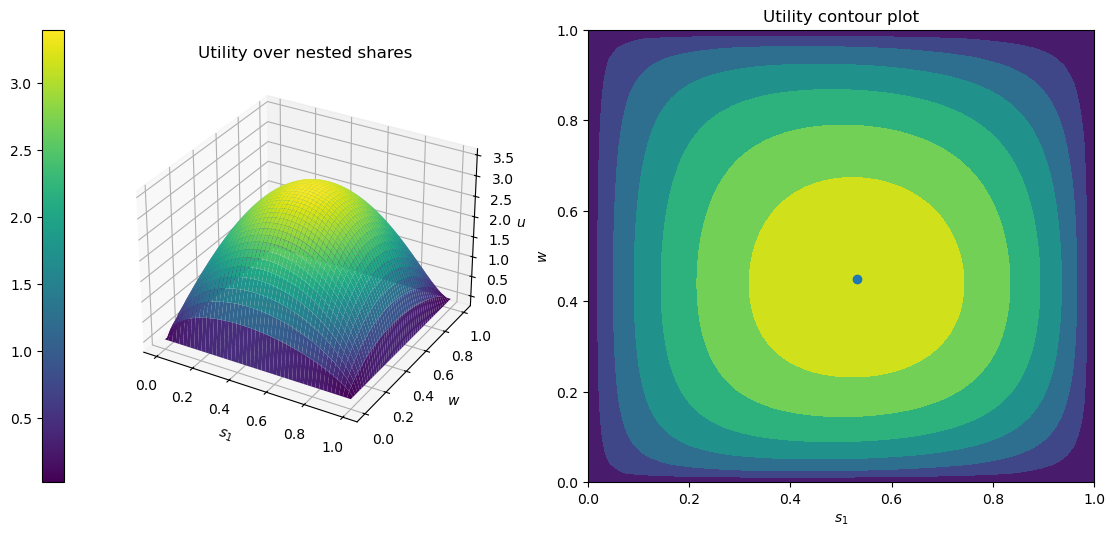

In [60]:
from Our_Consumer import ConsumerClass

model = ConsumerClass()

grid_N50 = model.solve_grid(N=50)

fig= model.plot_grid(grid_N50)


s1=0.5354
s2=0.2065
s3=0.2581
w=0.4444
u=3.4015


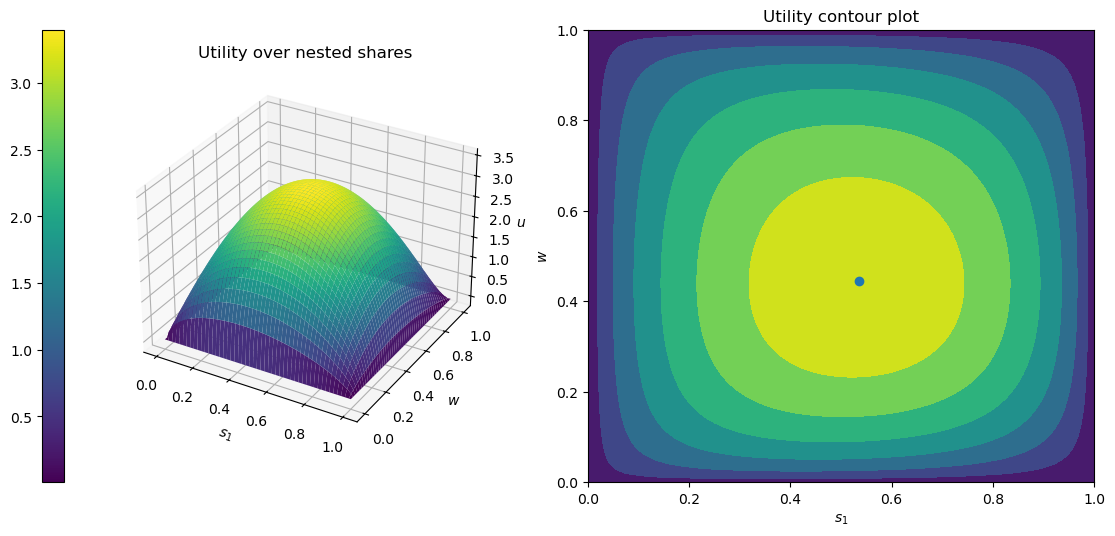

In [61]:
grid_N100 = model.solve_grid(N=100)
fig= model.plot_grid(grid_N100)

s1=0.5351
s2=0.2040
s3=0.2609
w=0.4389
u=3.4017


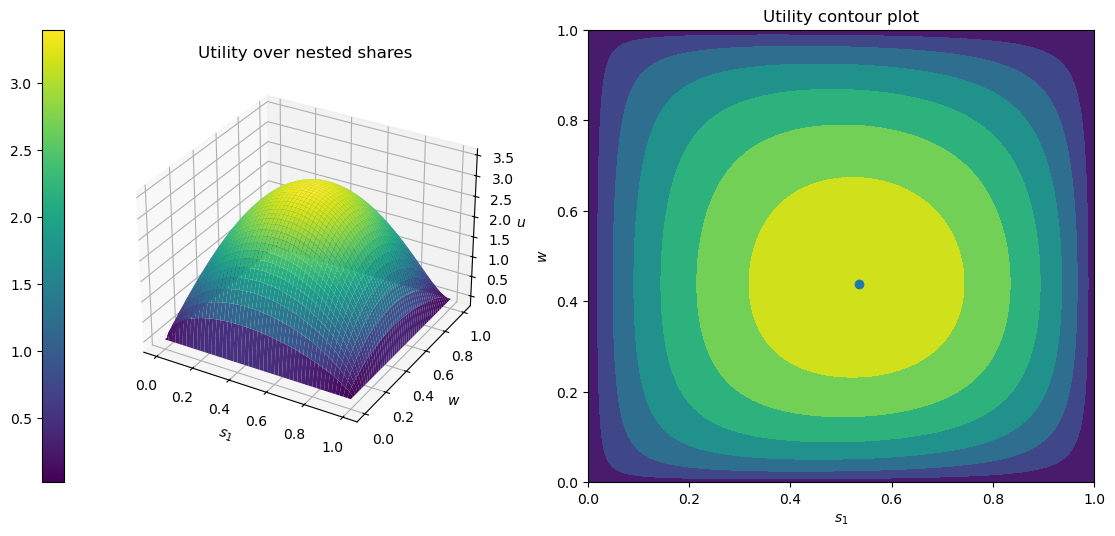

In [62]:
grid_N500 = model.solve_grid(N=500)
fig= model.plot_grid(grid_N500)

s1=0.5355
s2=0.2041
s3=0.2604
w=0.4394
u=3.4017


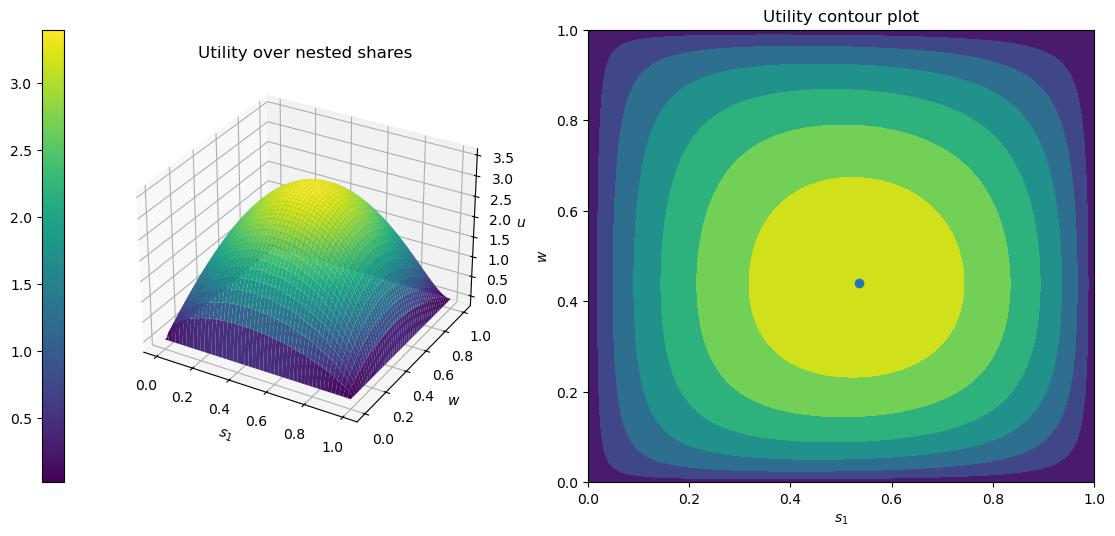

In [63]:
grid_N1000 = model.solve_grid(N=1000)
fig= model.plot_grid(grid_N1000)

#### Bus and trains subtitutes

s1=0.5306
s2=0.3257
s3=0.1437
w=0.6939
u=3.4846


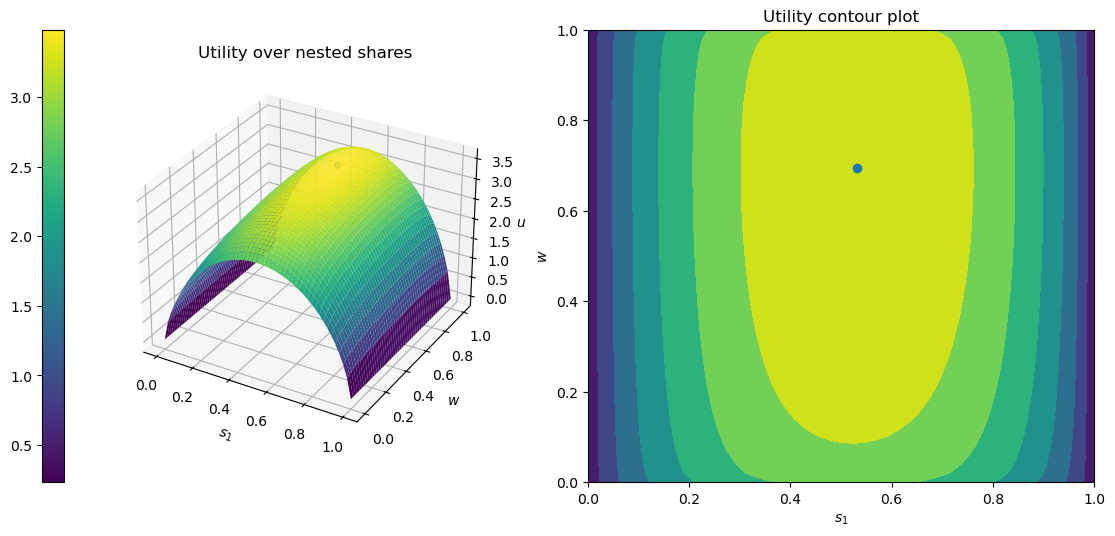

In [64]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=50)
fig= model_subtitutes.plot_grid(opt_subtitutes)

s1=0.5354
s2=0.3238
s3=0.1408
w=0.6970
u=3.4850


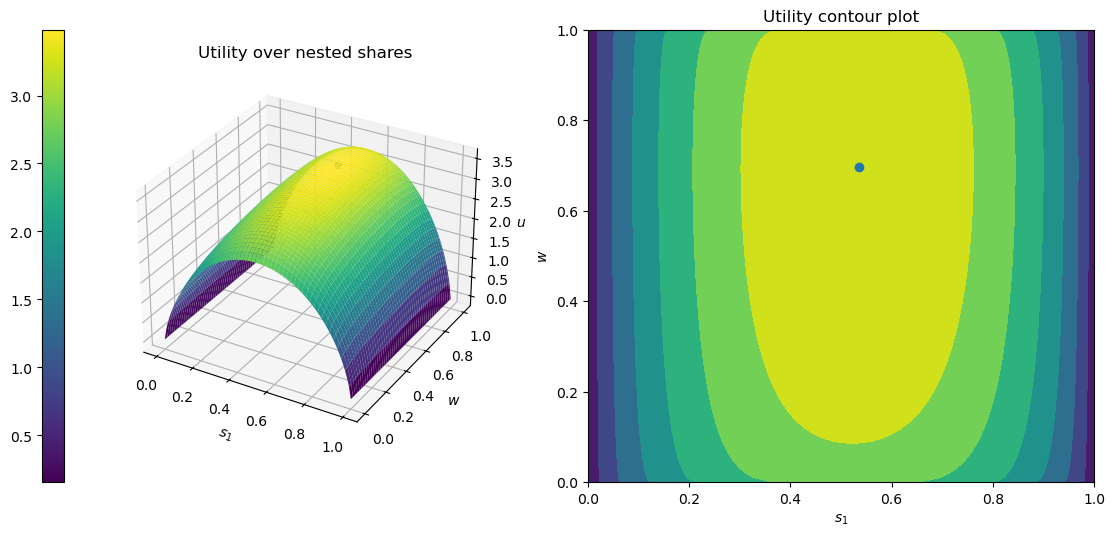

In [65]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=100)
fig= model_subtitutes.plot_grid(opt_subtitutes)

s1=0.5391
s2=0.3187
s3=0.1422
w=0.6914
u=3.4851


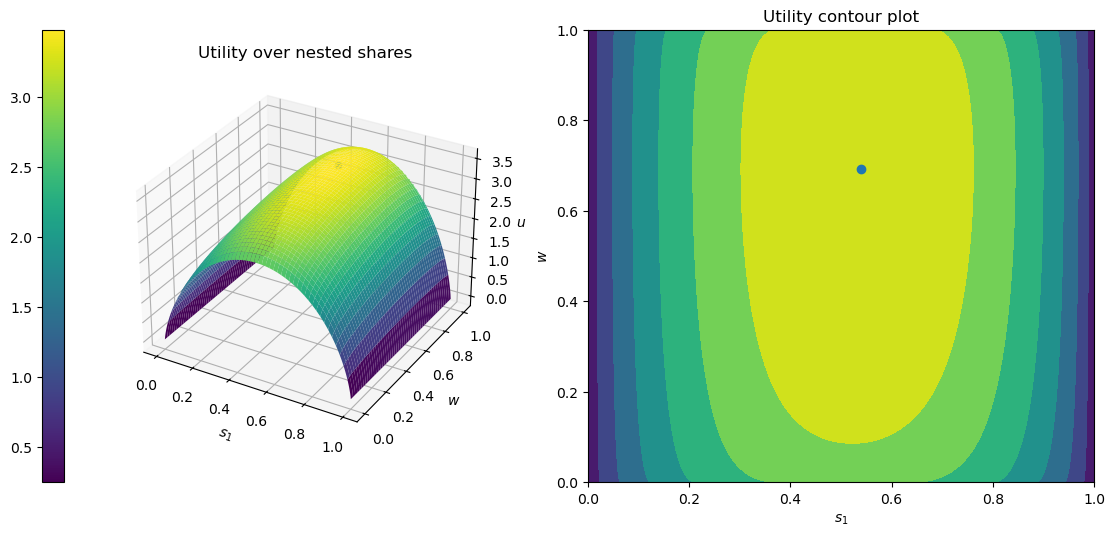

In [66]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=500)
fig= model_subtitutes.plot_grid(opt_subtitutes)

s1=0.5385
s2=0.3197
s3=0.1418
w=0.6927
u=3.4851


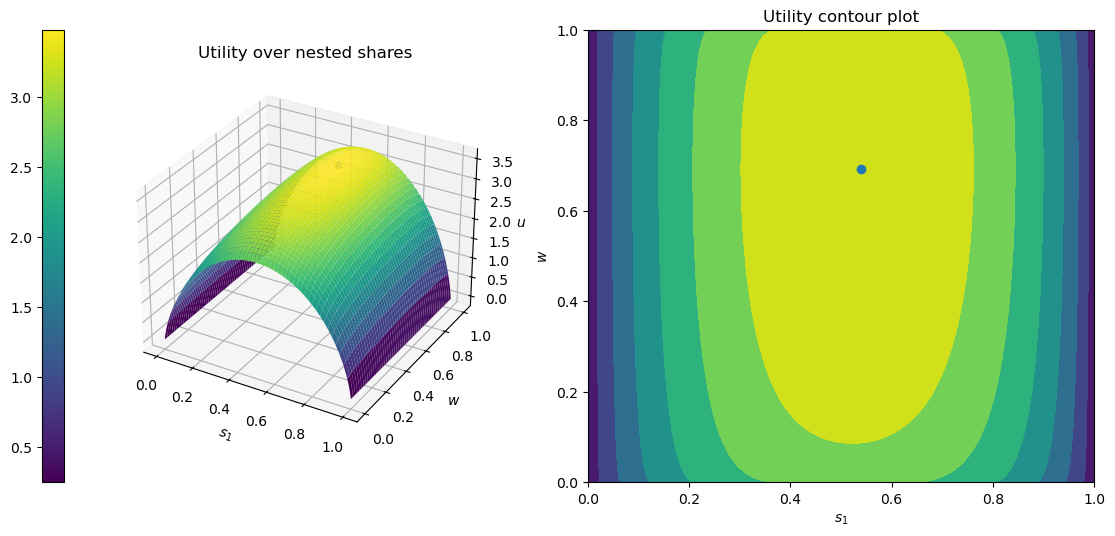

In [67]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=1000)
fig= model_subtitutes.plot_grid(opt_subtitutes)

#### The cost of one ekstra u

A problem of size  N cost N^2 evaluations of u. 

When we add one ekstra N, the expression becomes:
(N+1)(N+1) = N^2+2N+1

If we subtract the original cost (N^2), from the cost when adding one ekstra N we get:

N^2-N^2+2N+1 = 2N+1

This means that each time N is increased by 1, it requires 2N+1 additional evaluations of u.




#### How does increasing N improve u?

An increase in N expands the grid used in the search, which increases the amount of points to choose from. This improves the chance of finding the true optimal point, which is why u grows slightly as N increase:

u = 3.4007 (N=50)
u = 3.4015 (N=100)
u = 3.4017 (N=500)
u = 3.4017 (N=1000)

However,the gain in u shrinks quickly as N increase, while the cost keeps growing, since eazch additional N cost 2N+1 extra valuations of u. Beyond N=500 the gain start to vanish. A finer grid gives more precise results, but at a certin point the cost of extra evaluations outweighs the improvement in u.

### 2.1.4 Comparing the two calibrations

#### Bus and train complements

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


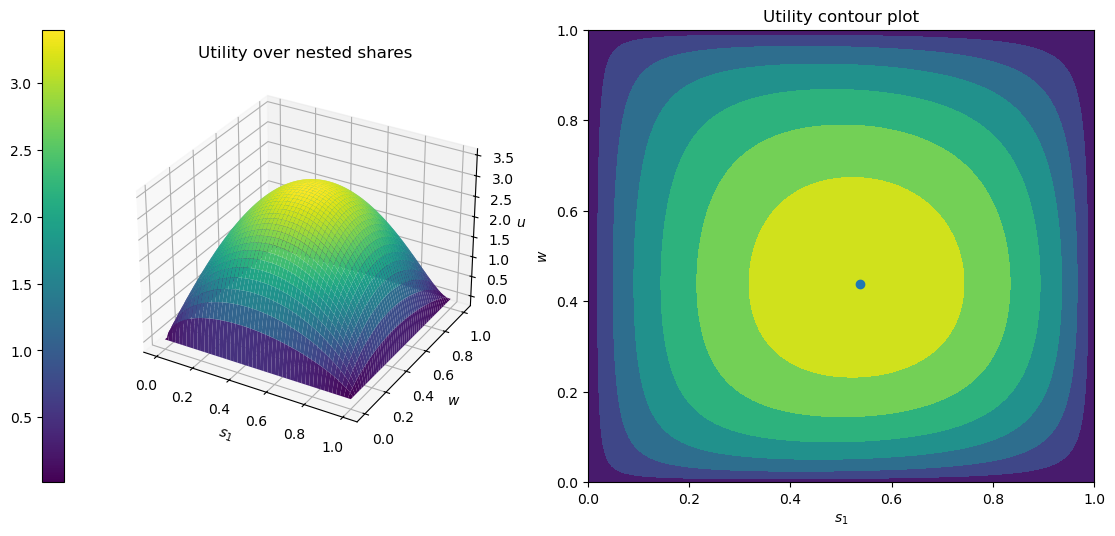

In [68]:
model_complements = ConsumerClass()

opt_complements = model_complements.solve_grid(N=200)
fig= model_complements.plot_grid(opt_complements)

When bus and train are complements the surface is a smooth rounded dome.The contour lines are formed in an oval shape around the optimum. The surface is steepest around the corners of the dome and gets flater the closer to the optimum it gets, but it doesn´t have a large flat area.

#### Bus and trains subtitutes

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


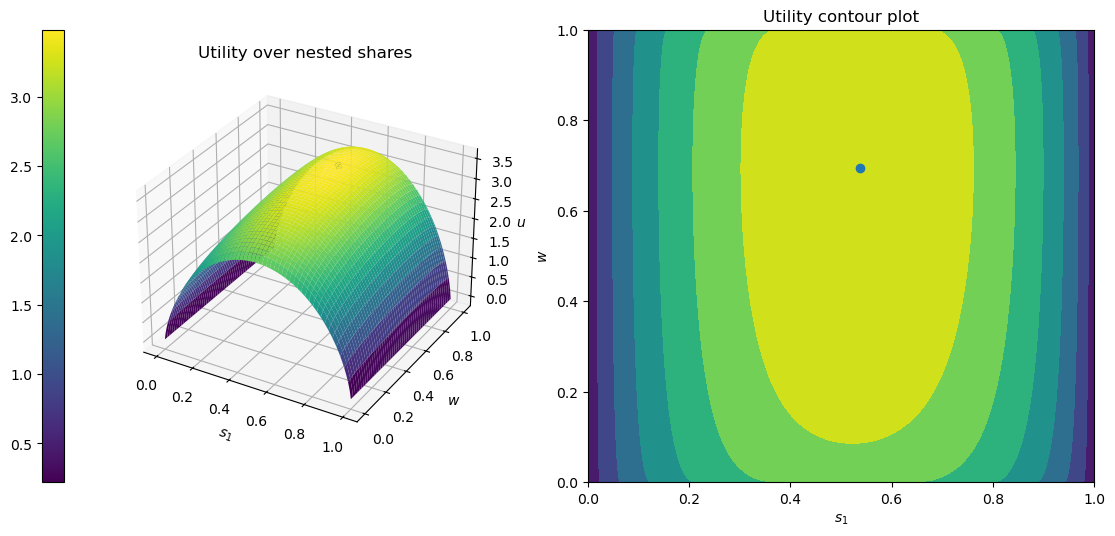

In [69]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=200)
fig= model_subtitutes.plot_grid(opt_subtitutes)

The surface looks very different when bus and train are substitutes. Now it looks more like a curved tunnel. The contour lines are very steep in the two sides of the surface, but it gets a bit flatter the closer to the top it gets. Utility thereby only changes very slightly as w increases, but it falls heavily when s1 moves away from its optimal point. The surface is thereby relatively flat around the w-axis, when s1 is at its optimal point.

#### Comparison of the two calibrations

We expect the substitute calibration to be the hardest one to optimize, because it has a bigger flatter area compared to the complement calibration. Even though the substitute calibration reaches the highest utility, it has a large area where the gradient is close to zero. This makes it harder for the optimizer to find the optimal value of w because the utility only changes very slightly as w increases, thereby making it hard for the optimizer to know what direction to move.

### 2.2.1 solution L-BFGS-B

#### Bus and train complements

In [70]:
from Our_Consumer import ConsumerClass

consumer = ConsumerClass()
solution_complements = consumer.solve()

print(f"u: {-solution_complements.res.fun}, initerations: {solution_complements.res.nit}")

u: 3.401679875985606, initerations: 4


#### Bus and trains subtitutes

In [71]:
consumer_substitutes = ConsumerClass(par={"sigma_B":3.0})
solution_substitutes = consumer_substitutes.solve()

print(f"u: {-solution_substitutes.res.fun}, initerations: {solution_substitutes.res.nit}")

u: 3.485104590431205, initerations: 6


#### Do the two methods agree

Yes, the two methods do agree. When doing the grid search when bus and train tickets are complements we get u=3.4016 for N=200. When using L-BFGS-B we get u=3.40168. When doing the grid search when bus and train tickets are subtitutes we get u=3.4851 for N=200. The two methods thus return the same result up to and including the fourth decimal. The grid search has almost no running time when N=200. However, the higher N gets the longer the running time gets. The L-BFGS-B method is quicker the closer the starting point is to the optimum point. Here we use the starting point (0.5 , 0.5) which happends to be fairly close to the optimum point resulting in the method only using four initerations to reach the optimum point.


### 2.2.2 The convergenze path

#### Bus and train complements

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


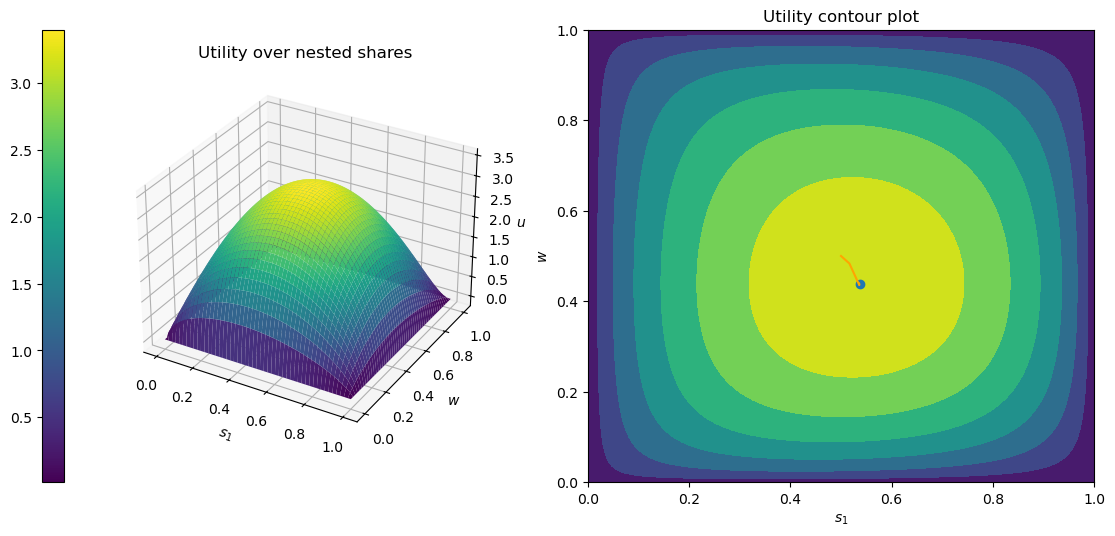

In [72]:
opt_grid = model.solve_grid(N=200)
opt_lbfgsb = model.solve()

fig = model.plot_grid(opt_grid)
ax = fig.axes[2]
ax.plot(opt_lbfgsb.path[:,0],opt_lbfgsb.path[:,1], color="orange")

In [73]:
opt_lbfgsb.path

array([[0.5       , 0.5       ],
       [0.51661738, 0.48338262],
       [0.5360763 , 0.43575106],
       [0.53560667, 0.43965199],
       [0.53562338, 0.43947903]])

In [74]:
path_com = solution_complements.path
xy_values_comp = solution_complements.res.x

distance_comp = np.linalg.norm(path_com - xy_values_comp, axis=1)
np.log(distance_comp)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_15190/1606275580.py:5: RuntimeWarning: divide by zero encountered in log
  np.log(distance_comp)


array([-2.65602428, -3.03987393, -5.58456487, -8.65778049,        -inf])

In [75]:
log_dis_comp = np.log(distance_comp)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_15190/1698964917.py:1: RuntimeWarning: divide by zero encountered in log
  log_dis_comp = np.log(distance_comp)


In [76]:
# Checking that the log calculation is correct
np.log(np.sqrt((0.5-0.53562338)**2 + (0.5-0.43947903)**2))

np.float64(-2.6560243037722415)

(-0.15000000000000002, 3.15)

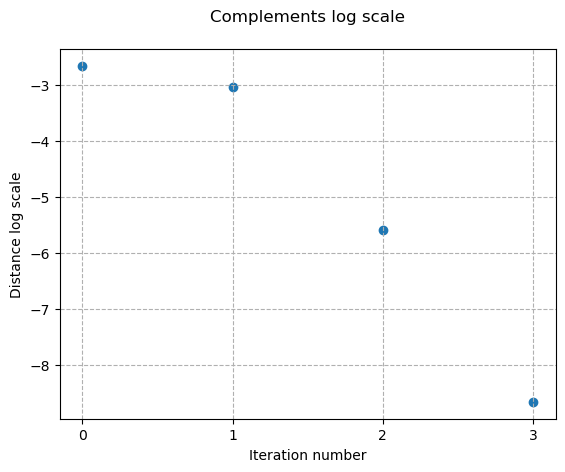

In [77]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.grid(True, ls="--")
ax.scatter(range(len(log_dis_comp)),log_dis_comp)

ax.set_title('Complements log scale',pad=20)
ax.set_xlabel('Iteration number')
ax.set_ylabel('Distance log scale')

ax.set_xticks(range(4))
ax.set_xlim()

#### Bus and trains subtitutes

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


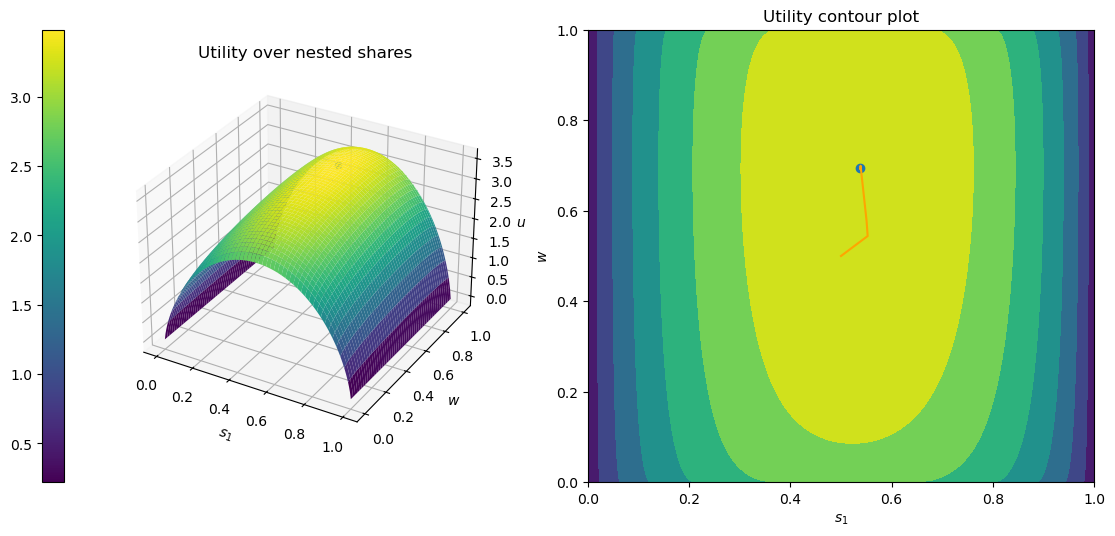

In [78]:
consumer_substitutes = ConsumerClass(par={"sigma_B":3.0})

opt_grid = consumer_substitutes.solve_grid(N=200)
opt_lbfgsb_sub = consumer_substitutes.solve()

fig = consumer_substitutes.plot_grid(opt_grid)
ax = fig.axes[2]
ax.plot(opt_lbfgsb_sub.path[:,0],opt_lbfgsb_sub.path[:,1], color="orange")

In [79]:
opt_lbfgsb_sub.path

array([[0.5       , 0.5       ],
       [0.55264991, 0.54406178],
       [0.55047615, 0.57788281],
       [0.53867585, 0.69929484],
       [0.5381552 , 0.69156192],
       [0.53822567, 0.69230085],
       [0.53822534, 0.69230777]])

In [80]:
path_sub = solution_substitutes.path
xy_values_sub= solution_substitutes.res.x

distance_sub = np.linalg.norm(path_sub - xy_values_sub, axis=1)
np.log(distance_sub)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_15190/3906373334.py:5: RuntimeWarning: divide by zero encountered in log
  np.log(distance_sub)


array([ -1.62928341,  -1.90417079,  -2.16213728,  -4.96161912,
        -7.19659223, -11.88039798,         -inf])

In [81]:
log_dis_sub = np.log(distance_sub)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_15190/1163028884.py:1: RuntimeWarning: divide by zero encountered in log
  log_dis_sub = np.log(distance_sub)


In [82]:
# Checking that the log calculation is correct
np.log(np.sqrt((0.5-0.53822534)**2 + (0.5-0.69230777)**2))

np.float64(-1.6292834090265513)

(-0.25, 5.25)

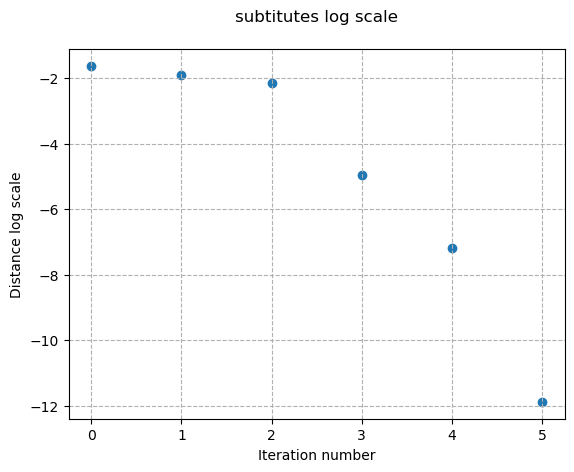

In [83]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.grid(True, ls="--")
ax.scatter(range(len(log_dis_sub)),log_dis_sub)

ax.set_title('subtitutes log scale',pad=20)
ax.set_xlabel('Iteration number')
ax.set_ylabel('Distance log scale')

ax.set_xticks(range(6))
ax.set_xlim()

#### Where does the method make fast progress, and where is it slow
The process is fast when the starting point is close to the optimal point. The closer the starting point the fewer iterations does the method neds. The further away the starting point is from the optimal point, the more iterations it needs and thelonger the methods takes

### 2.2.3 Solving with different starting points


#### Bus and train complements

In [84]:
from Our_Consumer import ConsumerClass

s_point_center = model.solve(s0=np.array([0.5,0.5]))
print(f"u: {-s_point_center.res.fun}, initerations: {s_point_center.res.nit}")

u: 3.401679875985606, initerations: 4


In [85]:
s_point_00 = model.solve(s0=np.array([0,0]))
print(f"u: {-s_point_00.res.fun}, initerations: {s_point_00.res.nit}")

u: 3.401679875987522, initerations: 7


In [86]:
s_point_01 = model.solve(s0=np.array([0,1]))
print(f"u: {-s_point_01.res.fun}, initerations: {s_point_01.res.nit}")

u: 3.401679875988759, initerations: 9


In [87]:
s_point_10 =model.solve(s0=(1,0))
print(f"u: {-s_point_10.res.fun}, initerations: {s_point_10.res.nit}")

u: 6.177356919346663e-11, initerations: 1


In [88]:
s_point_11 =model.solve(s0=(1,1))
print(f"u: {-s_point_11.res.fun}, initerations: {s_point_11.res.nit}")

u: 6.17735691935048e-11, initerations: 1


In [89]:
s_point_random =model.solve(s0=np.array([0.3,0.7]))
print(f"u: {-s_point_random.res.fun}, initerations: {s_point_random.res.nit}")

u: 3.4016798759887488, initerations: 6


#### Bus and trains subtitutes

In [90]:
s1_point_center =consumer_substitutes.solve(s0=np.array([0.5,0.5]))
print(f"u: {-s1_point_center.res.fun}, initerations: {s1_point_center.res.nit}")

u: 3.485104590431205, initerations: 6


In [91]:
s1_point_00 =model_subtitutes.solve(s0=np.array([0,0]))
print(f"u: {-s1_point_00.res.fun}, initerations: {s1_point_00.res.nit}")

u: 3.485104590420858, initerations: 18


In [92]:
s1_point_01 =model_subtitutes.solve(s0=np.array([0,1]))
print(f"u: {-s1_point_01.res.fun}, initerations: {s1_point_01.res.nit}")

u: 3.4851045904312117, initerations: 17


In [93]:
s1_point_10 =model_subtitutes.solve(s0=np.array([1,0]))
print(f"u: {-s1_point_10.res.fun}, initerations: {s1_point_10.res.nit}")

u: 3.4851045904312117, initerations: 18


In [94]:
s1_point_11 =model_subtitutes.solve(s0=np.array([1,1]))
print(f"u: {-s1_point_11.res.fun}, initerations: {s1_point_11.res.nit}")

u: 3.485104590431182, initerations: 16


In [95]:
s1_point_random =model_subtitutes.solve(s0=np.array([0.3,0.7]))
print(f"u: {-s1_point_random.res.fun}, initerations: {s1_point_random.res.nit}")

u: 3.4851045904309936, initerations: 7


#### Results and number of iterations

When bus and trains tickets are complements the L-BFGS-B method doesn´t reach the same u-value regardless of the starting point. At the two corners (1,0) and (1,1) it returns a really small value of u = 6.18e-11. This happens because s2 and s3 are zero when s1=1, which makes it report success = True even though only one iteration has occurd.

When bus and train tickets are substitutes the L-BFGS-B method reaches the same u-value regardless of the starting point. The choice of starting point only affects the number of iterations needed to reach the optimum point.

### 2.2.4 Varying the settings

In [96]:
# Getting the names of the variables

model.solve(s0=np.array([0.5,0.5]), options={'ftol':1e-1})

namespace(s1=np.float64(0.5166173782962519),
          w=np.float64(0.4833826217037481),
          s2=np.float64(0.23365875896518887),
          s3=np.float64(0.24972386273855926),
          u=np.float64(3.383679588967678),
          path=array([[0.5       , 0.5       ],
                      [0.51661738, 0.48338262]]),
          res=  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
                success: True
                 status: 0
                    fun: -3.383679588967678
                      x: [ 5.166e-01  4.834e-01]
                    nit: 1
                    jac: [-3.137e-01  6.724e-01]
                   nfev: 9
                   njev: 3
               hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)

#### Bus and train complements

In [97]:
for ftol in [10**-4,10**-8,10**-12,10**-16]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'ftol':ftol})
    print(ftol, report.res.x, -report.res.fun, report.res.nfev)

0.0001 [0.53560667 0.43965199] 3.4016796321211804 15
1e-08 [0.53562338 0.43947903] 3.401679875985606 18
1e-12 [0.53562338 0.43947903] 3.401679875985606 18
1e-16 [0.53562338 0.43947903] 3.401679875985606 18


In [144]:
import pandas as pd


table = []
for ftol in [10**-4,10**-8,10**-12,10**-16]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'ftol':ftol})
    table.append({
        "ftol" : ftol,
        "s1" : report.res.x[0], 
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev, 
    })

ftol_compl = pd.DataFrame(table)
ftol_compl.style.format({
"ftol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})

,ftol,s1,w,u,iterations
0,1.0e-04,0.5382,0.6916,3.48510385,21
1,1.0e-08,0.5382,0.6923,3.48510459,27
2,1.0e-12,0.5382,0.6923,3.48510459,27
3,1.0e-16,0.5382,0.6923,3.48510459,27


In [145]:
for gtol in [10**-2,10**-5,10**-8,10**-12]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'gtol':gtol})
    print(gtol, report.res.x, -report.res.fun, report.res.nfev)

0.01 [0.5381552  0.69156192] 3.4851038474276494 21
1e-05 [0.53822534 0.69230777] 3.485104590431205 27
1e-08 [0.53822534 0.69230777] 3.485104590431205 27
1e-12 [0.53822534 0.69230777] 3.485104590431205 27


In [146]:
table = []
for gtol in [10**-2,10**-5,10**-8,10**-12]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'gtol':gtol})
    table.append({
        "gtol" : gtol,
        "s1" : report.res.x[0],
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev
    })

gtol_compl = pd.DataFrame(table)
gtol_compl.style.format({
"gtol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})


,gtol,s1,w,u,iterations
0,1.0e-02,0.5382,0.6916,3.48510385,21
1,1.0e-05,0.5382,0.6923,3.48510459,27
2,1.0e-08,0.5382,0.6923,3.48510459,27
3,1.0e-12,0.5382,0.6923,3.48510459,27


#### Bus and trains subtitutes

In [147]:
model.par.sigma_B = 3.0

table = []
for ftol in [10**-4,10**-8,10**-12,10**-16]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'ftol':ftol})
    table.append({
        "ftol" : ftol,
        "s1" : report.res.x[0],
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev
    })

ftol_sub = pd.DataFrame(table)
ftol_sub.style.format({
"ftol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})

,ftol,s1,w,u,iterations
0,1.0e-04,0.5382,0.6916,3.48510385,21
1,1.0e-08,0.5382,0.6923,3.48510459,27
2,1.0e-12,0.5382,0.6923,3.48510459,27
3,1.0e-16,0.5382,0.6923,3.48510459,27


In [148]:
model.par.sigma_B = 3.0

table = []
for gtol in [10**-2,10**-5,10**-8,10**-12]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'gtol':gtol})
    table.append({
        "gtol" : gtol,
        "s1" : report.res.x[0],
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev
    })

gtol_sub = pd.DataFrame(table)
gtol_compl = pd.DataFrame(table)
gtol_compl.style.format({
"gtol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})


,gtol,s1,w,u,iterations
0,1.0e-02,0.5382,0.6916,3.48510385,21
1,1.0e-05,0.5382,0.6923,3.48510459,27
2,1.0e-08,0.5382,0.6923,3.48510459,27
3,1.0e-12,0.5382,0.6923,3.48510459,27


### 2.2.5 What settings would we use

We would use the settings ftol=10**-4 and gtol=10**-5, because theese gives the highest values of u while limitting the number of iritations needed.
A tigher tolerance isn´t alway a better choice, beacause at some point it no longer improves u, but inly increases the number of iritations needed. This is also the case in 2.2.4, where u at some point stays the same, but the number og iritations increase as the valuse of ftol and gtol gets tightened further.